<a href="https://colab.research.google.com/github/annhater/M1_STAGE/blob/main/03_plot_HB_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intraprotein H-Bond Network — Full Residue Graph

**What this notebook does:**

Reproduces the network figure from the paper (Figure 4):
- **Nodes** represent residues across the full protein
  - Circle nodes → chain A  |  Square nodes → chain B
  - **Node size** ∝ total number of H-bonds made by that residue
  - **Node colour** → residue type classification (editable in Configuration)
- **Edges** represent H-bond interactions averaged across all simulations
  - **Edge width & opacity** ∝ mean interaction frequency (%)
  - Only edges whose mean frequency exceeds `MIN_EDGE_FREQ` are drawn

**Input:**
The per-simulation interaction CSV files from your GROMACS pipeline
(e.g. `res_V1.csv`). Column naming convention: `hbXX_RES_RESNUM_ATOM_RES_RESNUM_ATOM`

**Sections:**
1. Install & import libraries
2. Configuration
3. Helper functions (bond parser, colour/shape/size logic)
4. Load CSVs and compute per-bond mean frequency
5. Build edge list
6. Compute per-node bond count
7. Build igraph network and assign attributes
8. Compute layout
9. Render with matplotlib
10. Save figure
11. Export to GraphML (optional — for Gephi / Cytoscape)

In [1]:
!pip install igraph pycairo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 21.4 MB/s eta 0:00:00


In [3]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import igraph as ig
import random as rd

warnings.filterwarnings('ignore')

In [4]:
ROOTDIR    = '/content/drive/MyDrive/M1_STAGE/Data/interactions/'
OUTPUT_FIG = '/content/drive/MyDrive/M1_STAGE/Manips/Figures/hbond_network_full.png'
os.chdir(ROOTDIR)

In [52]:

# Paths

# Interaction CSV files (one per simulation)
INTERACTION_FILES = [
    'res_V7.csv', 'res_V8.csv', 'res_V21.csv'
]
SIMULATION_NAMES = ['V1', 'V11', 'V12', 'V7', 'V8', 'V21']

# ── Edge filtering ───────────────────────────────────────────────────────────
# Only draw an edge if mean frequency across simulations >= this value (%)
MIN_EDGE_FREQ = 10.0

# ── Chain boundary ───────────────────────────────────────────────────────────
# Residue numbers 1–99  → chain A
# Residue numbers 100+  → chain B  (displayed as local_num = resnum - 99)
CHAIN_A_MAX_RESNUM = 99

RESIDUE_TYPE_MAP = {
    # Example entries — replace / extend with your data:
     ('ASP',  25): 'I',
     ('ASP', 124): 'I',
     ('THR',  26): 'II',
     ('GLY',  10): 'IV',
}

# Residue numbers (local, 1-99) whose structural letter is undefined → light blue
UNCLASSIFIED_LOCAL_RESNUMS = {1, 2, 99}

TYPE_COLORS = {
    'I':   '#1f4e97',   # deep blue
    'II':  '#00bcd4',   # cyan
    'III': '#f5a623',   # orange
    'IV':  '#d0021b',   # red
    'UNK': '#a8c8e8',   # light blue (unclassified)
}
# New region definitions and colors
REGION_COLORS = {
    'N-terminus':     '#ADD8E6', # Light Blue
    'R1':             '#F08080', # Light Coral
    'fulcrum':        '#90EE90', # Light Green
    'catalytic site': '#FF6961', # Pastel Red
    'R2':             '#DDA0DD', # Plum
    'elbows':         '#87CEEB', # Sky Blue
    'flaps':          '#FFC067', # Pastel Orange
    'cantilever':     '#3CB371', # Medium Sea Green
    'R3':             '#FF8C00', # Dark Orange
    'wall':           '#9370DB', # Medium Purple
    'R4':             '#228B22', # Forest Green
    'alpha-helix':    '#D2691E', # Chocolate
    'C-terminus':     '#A9A9A9', # Dark Grey
    'UNK':            '#A8C8E8', # Light Blue (unclassified - fallback)
}

REGION_RANGES = [
    (1, 4, 'N-terminus'),
    (5, 9, 'R1'),
    (10, 23, 'fulcrum'),
    (24, 30, 'catalytic site'),
    (31, 36, 'R2'),
    (37, 42, 'elbows'),
    (43, 58, 'flaps'),
    (59, 75, 'cantilever'),
    (76, 79, 'R3'),
    (80, 83, 'wall'),
    (84, 86, 'R4'),
    (87, 95, 'alpha-helix'),
    (96, 99, 'C-terminus'),
]

# ── Node sizing ──────────────────────────────────────────────────────────────
NODE_SIZE_MIN = 12    # minimum node radius (matplotlib units)
NODE_SIZE_MAX = 40    # maximum node radius

# ── Edge styling ─────────────────────────────────────────────────────────────
EDGE_WIDTH_MAX = 5.0    # maximum line width
EDGE_ALPHA_MIN = 0.20   # minimum edge opacity

In [53]:
LAYOUT_ALGO = 'fr'    # 'fr' = Fruchterman-Reingold; 'kk' = Kamada-Kawai
LAYOUT_ITER = 2000
RANDOM_SEED = rd.randint(1,100)

In [54]:
def parse_bond_name(col: str):
    without_prefix = re.sub(r'^hb\\w{2}_', '', col)
    parts = without_prefix.split('_')
    if len(parts) >= 6:
        try:
            result = {
                'resname1': parts[1],
                'resnum1': int(parts[2]),
                'atom1': parts[3],
                'resname2': parts[4],
                'resnum2': int(parts[5]),
                'atom2': parts[6]
            }
            return result
        except (ValueError, IndexError):
            return None
    return None


def get_chain(resnum: int) -> str:
    return 'A' if resnum <= CHAIN_A_MAX_RESNUM else 'B'


def get_local_resnum(resnum: int) -> int:
    return resnum if get_chain(resnum) == 'A' else resnum - CHAIN_A_MAX_RESNUM


def residue_key(resname: str, resnum: int) -> str:
    return f'{resname}_{resnum}'


def residue_label(resnum: int) -> str:
    return f'{get_local_resnum(resnum)}{get_chain(resnum)}'

def get_node_color(resname: str, resnum: int) -> str:
    local = get_local_resnum(resnum)
    for start, end, region_name in REGION_RANGES:
        if start <= local <= end:
            return REGION_COLORS.get(region_name, REGION_COLORS['UNK'])
    return REGION_COLORS['UNK'] # Default for anything not in a region


def get_node_shape(resnum: int) -> str:
    return 'circle' if get_chain(resnum) == 'A' else 'square'


def scale_node_size(count: int, min_c: int, max_c: int) -> float:
    if max_c == min_c:
        return (NODE_SIZE_MIN + NODE_SIZE_MAX) / 2
    t = (count - min_c) / (max_c - min_c)
    return NODE_SIZE_MIN + t * (NODE_SIZE_MAX - NODE_SIZE_MIN)


In [20]:
''' def parse_bond_name(col: str):
    without_prefix = re.sub(r'^hb\\w*_', '', col)
    parts = without_prefix.split('_')
    # Expected: [RES, NUM, ATOM, RES, NUM, ATOM, ...]
    if len(parts) >= 6:
        try:
            return {
                'resname1': parts[1],
                'resnum1': int(parts[2]),
                'atom1': parts[3],
                'resname2': parts[4],
                'resnum2': int(parts[5]),
                'atom2': parts[6]
            }
        except (ValueError, IndexError):
            return None
    return None


def get_chain(resnum: int) -> str:
    return 'A' if resnum <= CHAIN_A_MAX_RESNUM else 'B'


def get_local_resnum(resnum: int) -> int:
    return resnum if get_chain(resnum) == 'A' else resnum - CHAIN_A_MAX_RESNUM


def residue_key(resname: str, resnum: int) -> str:
    return f'{resname}_{resnum}'


def residue_label(resnum: int) -> str:
    return f'{get_local_resnum(resnum)}{get_chain(resnum)}'


def get_node_color(resname: str, resnum: int) -> str:
    local = get_local_resnum(resnum)
    if local in UNCLASSIFIED_LOCAL_RESNUMS:
        return TYPE_COLORS['UNK']
    rtype = RESIDUE_TYPE_MAP.get((resname, resnum),
            RESIDUE_TYPE_MAP.get((resname, local), 'III'))
    return TYPE_COLORS.get(rtype, TYPE_COLORS['III'])


def get_node_shape(resnum: int) -> str:
    return 'circle' if get_chain(resnum) == 'A' else 'square'


def scale_node_size(count: int, min_c: int, max_c: int) -> float:
    if max_c == min_c:
        return (NODE_SIZE_MIN + NODE_SIZE_MAX) / 2
    t = (count - min_c) / (max_c - min_c)
    return NODE_SIZE_MIN + t * (NODE_SIZE_MAX - NODE_SIZE_MIN)
 '''

" def parse_bond_name(col: str):\n    without_prefix = re.sub(r'^hb\\w*_', '', col)\n    parts = without_prefix.split('_')\n    # Expected: [RES, NUM, ATOM, RES, NUM, ATOM, ...]\n    if len(parts) >= 6:\n        try:\n            return {\n                'resname1': parts[1],\n                'resnum1': int(parts[2]),\n                'atom1': parts[3],\n                'resname2': parts[4],\n                'resnum2': int(parts[5]),\n                'atom2': parts[6]\n            }\n        except (ValueError, IndexError):\n            return None\n    return None\n\n\ndef get_chain(resnum: int) -> str:\n    return 'A' if resnum <= CHAIN_A_MAX_RESNUM else 'B'\n\n\ndef get_local_resnum(resnum: int) -> int:\n    return resnum if get_chain(resnum) == 'A' else resnum - CHAIN_A_MAX_RESNUM\n\n\ndef residue_key(resname: str, resnum: int) -> str:\n    return f'{resname}_{resnum}'\n\n\ndef residue_label(resnum: int) -> str:\n    return f'{get_local_resnum(resnum)}{get_chain(resnum)}'\n\n\ndef

In [55]:
bond_freq_lists = {}   # bond_col → [freq_sim1, freq_sim2, ...]

for sim_file in INTERACTION_FILES:
    if not os.path.exists(sim_file):
        print(f'[WARN] {sim_file} not found — skipping.')
        continue
    df = pd.read_csv(sim_file)
    n_frames = len(df)
    for col in [c for c in df.columns if c.startswith('hb')]:
        freq = (df[col] > 0).sum() / n_frames * 100
        bond_freq_lists.setdefault(col, []).append(freq)

bond_mean_freq = {col: np.mean(freqs) for col, freqs in bond_freq_lists.items()}

print(f'Total unique H-bonds found  : {len(bond_mean_freq)}')
print(f'Bonds above {MIN_EDGE_FREQ}% mean freq : '
      f'{sum(v >= MIN_EDGE_FREQ for v in bond_mean_freq.values())}')

Total unique H-bonds found  : 1741
Bonds above 10.0% mean freq : 303


In [56]:
print(f"Checking {len(bond_mean_freq)} bonds with MIN_EDGE_FREQ={MIN_EDGE_FREQ}%")
for col, mean_freq in bond_mean_freq.items():
    if mean_freq < MIN_EDGE_FREQ:
        continue
    parsed = parse_bond_name(col)


Checking 1741 bonds with MIN_EDGE_FREQ=10.0%


In [57]:
# Multiple bonds between the same residue pair → keep the max mean frequency.

edge_dict   = {}   # (key1, key2) → max mean frequency
residue_info = {}  # key → (resname, resnum)

for col, mean_freq in bond_mean_freq.items():
    if mean_freq < MIN_EDGE_FREQ:
        continue
    parsed = parse_bond_name(col)
    if parsed is None:
        # print(f"Skipping bond '{col}' due to parsing error.") # Uncomment for verbose error logging
        continue
    r1n = parsed['resname1']
    r1num = parsed['resnum1']
    r2n = parsed['resname2']
    r2num = parsed['resnum2']
    k1 = residue_key(r1n, r1num)
    k2 = residue_key(r2n, r2num)
    # print(f"Processing: {col} -> k1={k1}, k2={k2}") # Debug print
    if k1 == k2:
        # print(f"  WARN: Skipping self-loop bond: {k1}-{k2}") # Debug print
        continue
    residue_info[k1] = (r1n, r1num)
    residue_info[k2] = (r2n, r2num)
    ekey = (min(k1, k2), max(k1, k2))
    edge_dict[ekey] = max(edge_dict.get(ekey, 0.0), mean_freq)

edges      = list(edge_dict.keys())
edge_freqs = [edge_dict[e] for e in edges]
node_keys  = sorted(residue_info.keys())

print(f'Nodes (residues) in network : {len(node_keys)}')
print(f'Edges (H-bond pairs)        : {len(edges)}')


Nodes (residues) in network : 179
Edges (H-bond pairs)        : 196


In [58]:
node_bond_count = {k: 0 for k in node_keys}
for (k1, k2) in edges:
    node_bond_count[k1] += 1
    node_bond_count[k2] += 1
min_c = min(node_bond_count.values())
max_c = max(node_bond_count.values())
print(f'Bond count per node: min={min_c}, max={max_c}')

Bond count per node: min=1, max=7


In [59]:

g = ig.Graph()
g.add_vertices(node_keys)
g.add_edges([(k1, k2) for k1, k2 in edges])
g.es['freq'] = edge_freqs

for v in g.vs:
    resname, resnum = residue_info[v['name']]
    v['color']      = get_node_color(resname, resnum)
    v['size']       = scale_node_size(node_bond_count[v['name']], min_c, max_c)
    v['shape']      = get_node_shape(resnum)
    v['label']      = residue_label(resnum)
    v['chain']      = get_chain(resnum)
    v['resnum']     = resnum
    v['bond_count'] = node_bond_count[v['name']]

max_freq = max(edge_freqs) if edge_freqs else 1.0

print(f'Graph: {g.vcount()} vertices, {g.ecount()} edges')

Graph: 179 vertices, 196 edges


In [60]:
np.random.seed(65)
layout = g.layout(LAYOUT_ALGO, niter=LAYOUT_ITER)
coords = np.array(layout.coords)

# Normalise to [0, 1] for matplotlib axes
xy_min = coords.min(axis=0)
xy_max = coords.max(axis=0)
span   = (xy_max - xy_min).clip(min=1e-6)
norm   = (coords - xy_min) / span

print('Layout computed.')
print(f'{RANDOM_SEED}')

Layout computed.
80


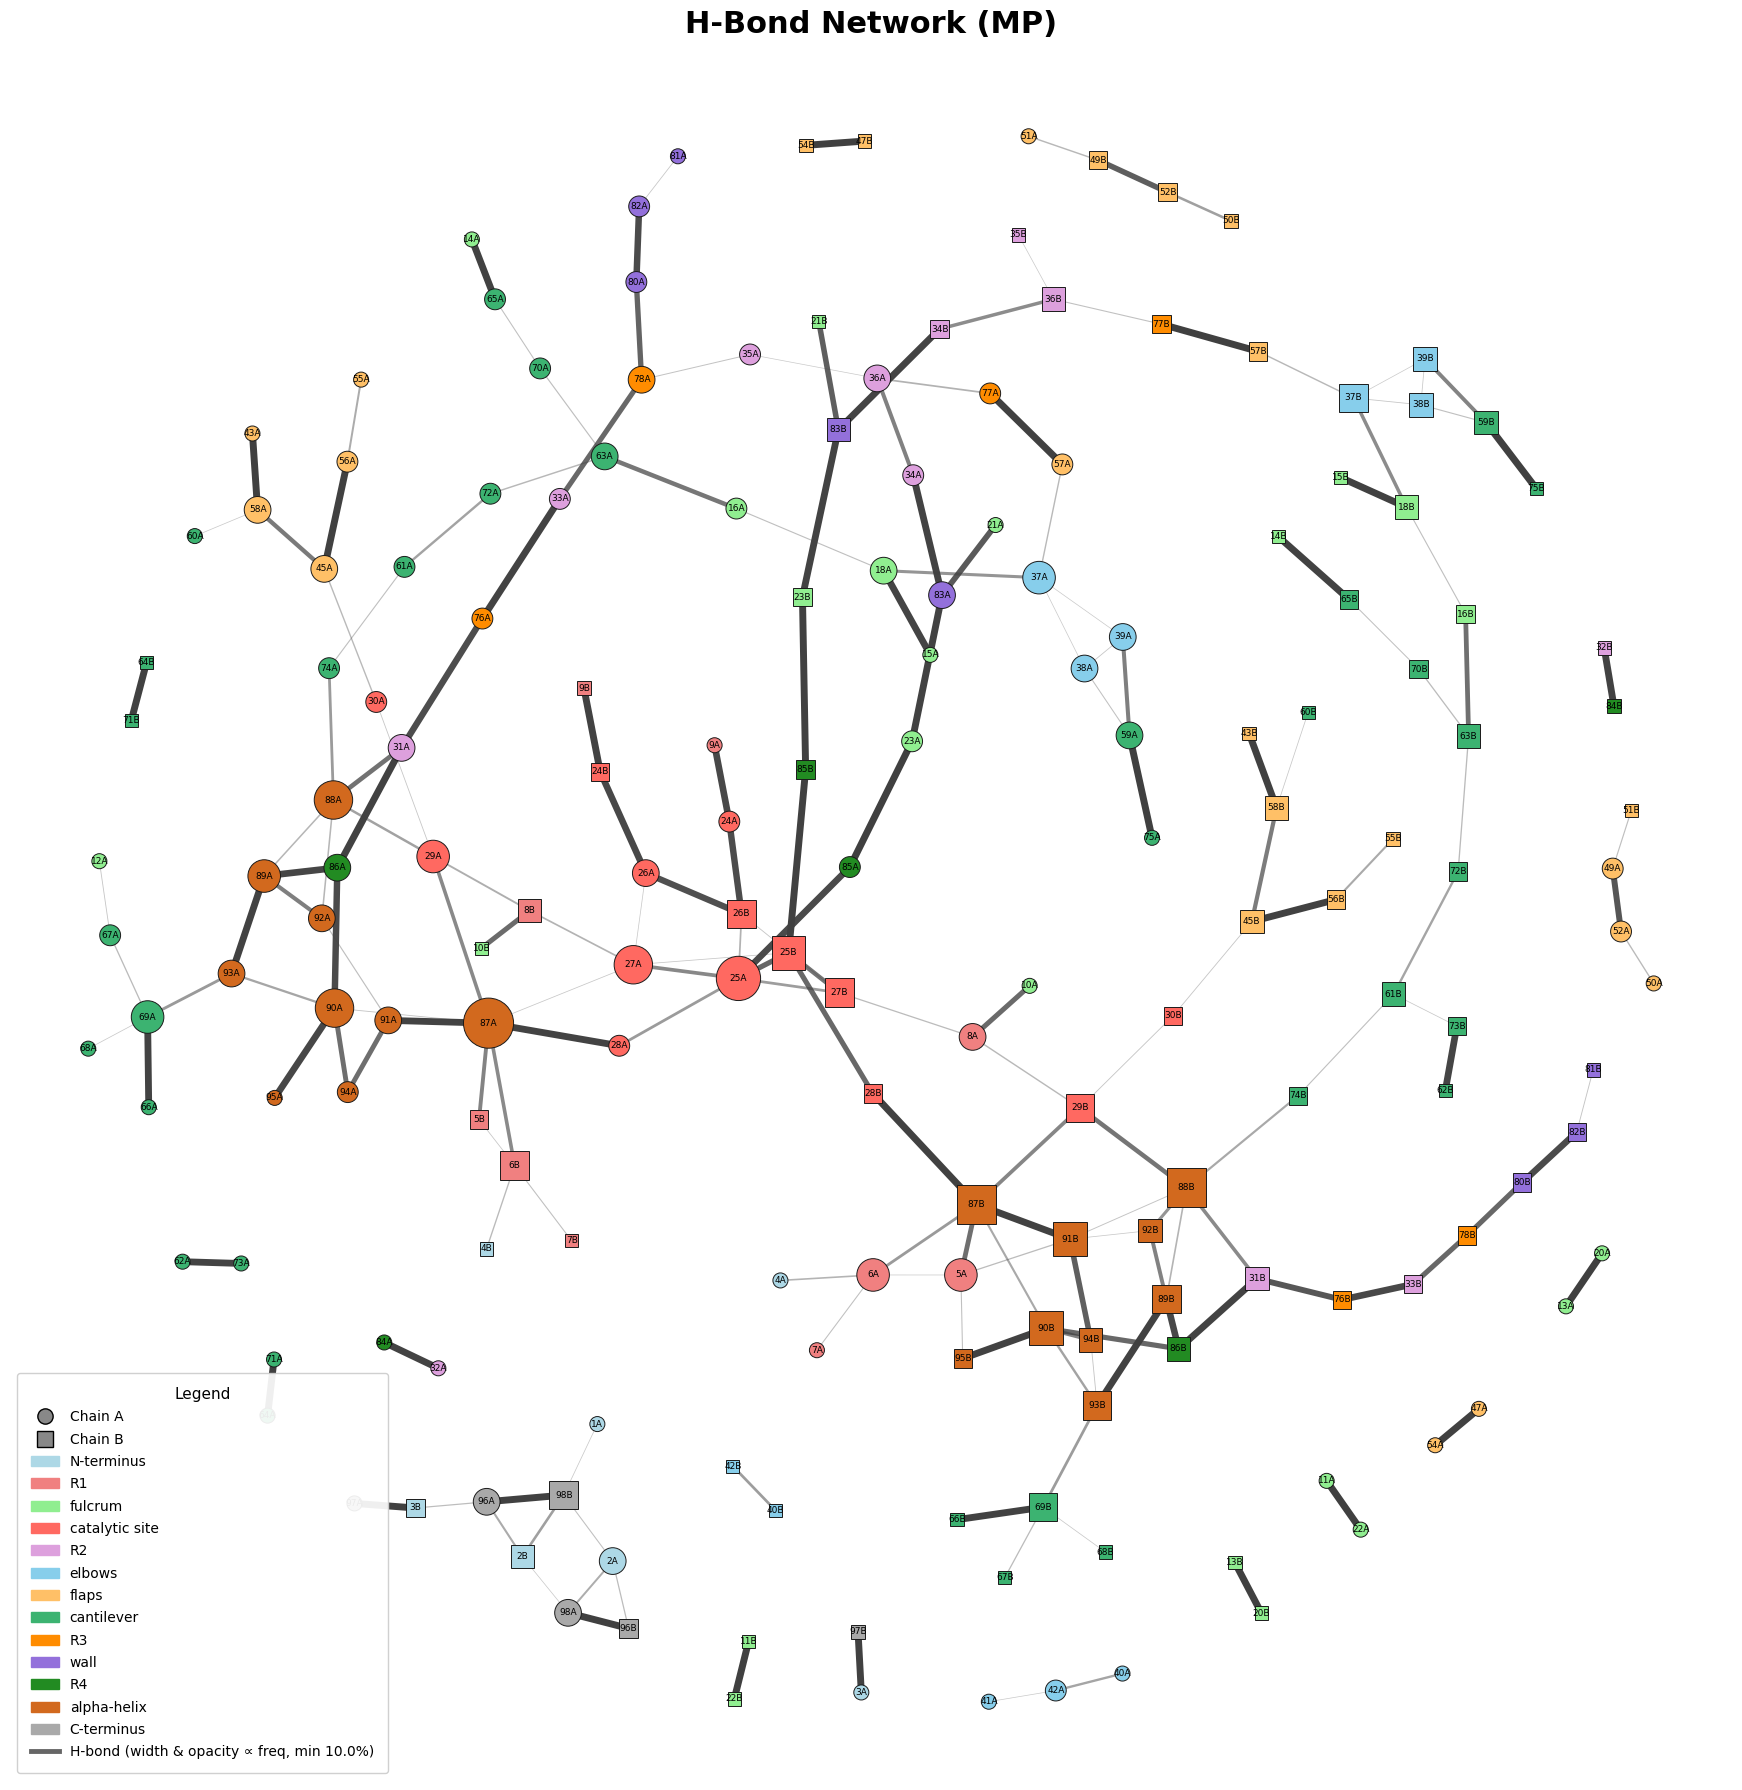

In [62]:
fig, ax = plt.subplots(figsize=(20, 18))
ax.set_aspect('equal')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.axis('off')
fig.patch.set_facecolor('white')
ax.set_title('H-Bond Network (MP)', fontsize=22, fontweight='bold', pad=18)

# ── Draw edges (behind nodes) ──────────────────────────────────────────────
for e in g.es:
    s, t   = e.source, e.target
    freq   = e['freq']
    alpha  = EDGE_ALPHA_MIN + (1.0 - EDGE_ALPHA_MIN) * (freq / max_freq)
    lw     = EDGE_WIDTH_MAX * (freq / max_freq)
    ax.plot([norm[s, 0], norm[t, 0]],
            [norm[s, 1], norm[t, 1]],
            '-', color='#404040', linewidth=lw, alpha=alpha, zorder=1, solid_capstyle='round')

# ── Draw nodes ──────────────────────────────────────────────────────────────
# NODE_SCALE controls the physical radius of nodes relative to the axes
NODE_SCALE = 0.016

for i, v in enumerate(g.vs):
    x, y   = norm[i]
    color  = v['color']
    size   = v['size']
    shape  = v['shape']
    label  = v['label']
    r      = NODE_SCALE * (size / NODE_SIZE_MAX)

    if shape == 'circle':
        patch = plt.Circle((x, y), r, fc=color, ec='#1a1a1a', lw=0.7, zorder=2)
    else:
        half  = r * 0.88   # squares slightly smaller so they look similar in area
        patch = plt.Rectangle((x - half, y - half), 2 * half, 2 * half,
                               fc=color, ec='#1a1a1a', lw=0.7, zorder=2)
    ax.add_patch(patch)

    light_colors = ['#ADD8E6', '#F08080', '#90EE90', '#FFD700', '#87CEEB', '#FA8072', '#A8C8E8']
    text_color = 'black'
    ax.text(x, y, label, ha='center', va='center',
            fontsize=6.5, fontweight='light', color=text_color, zorder=3)

# ── Legend ──────────────────────────────────────────────────────────────────
legend_elements_regions = []
for region_name, color_hex in REGION_COLORS.items():
    if region_name != 'UNK': # Add UNK separately if desired, or skip it
        legend_elements_regions.append(mpatches.Patch(color=color_hex, label=region_name))

legend_elements = [
    mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor='#888',
                  markersize=11, markeredgecolor='black', label='Chain A'),
    mlines.Line2D([0], [0], marker='s', color='w', markerfacecolor='#888',
                  markersize=11, markeredgecolor='black', label='Chain B'),
    ] + legend_elements_regions + [
    mlines.Line2D([0], [0], color='#404040', linewidth=3.5, alpha=0.8,
                  label=f'H-bond (width & opacity ∝ freq, min {MIN_EDGE_FREQ}%)'),
]
ax.legend(handles=legend_elements, loc='lower left',
          fontsize=10, frameon=True, framealpha=0.92,
          title='Legend', title_fontsize=11,
          borderpad=1.0, labelspacing=0.6)

plt.tight_layout()
plt.show()


In [ ]:
os.makedirs(os.path.dirname(OUTPUT_FIG), exist_ok=True)
fig.savefig(OUTPUT_FIG, dpi=300, bbox_inches='tight')
print(f'Saved to {OUTPUT_FIG}')

Saved to /content/drive/MyDrive/M1_STAGE/Manips/Figures/hbond_network_full.png


In [ ]:
graphml_path = OUTPUT_FIG.replace('.png', '.graphml')
g.write_graphml(graphml_path)
print(f'GraphML saved to {graphml_path}')

GraphML saved to /content/drive/MyDrive/M1_STAGE/Manips/Figures/hbond_network_full.graphml
